In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import ttest_ind

In [2]:
import seaborn as sns
print(sns.__version__)
import sklearn
print(sklearn.__version__)

0.13.2
1.5.1


In [3]:
def round_sig(x, sig=2):
#     To round to n significant digits (non-zero digits)
    if x == 0:
        return 0
    return round(x, sig - int(np.floor(np.log10(abs(x)))) - 1)

## Read Data

In [4]:
df_1_avg_persub = pd.read_csv('/Users/eweisbar/Documents/projects/MitoDonna/paper/aggregated_profiles_fibroblast.csv')

data_phs0 = df_1_avg_persub.groupby(['label','subject']).mean().reset_index()
data_phs_psych=data_phs0[data_phs0['label'].isin(["BP","SZ","SZA"])].copy()
data_phs_psych['label']='psychosis'
data_phs=pd.concat([data_phs0,data_phs_psych],ignore_index=True)

/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/229240507.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/229240507.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(labels)


0.029
0.031
0.12
0.16
0.81


/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/229240507.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/229240507.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(labels)


0.029
0.031
0.12
0.16
0.81


/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/229240507.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/229240507.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(labels)


0.0095
0.0046
0.095
0.26
0.59


/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/229240507.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/229240507.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(labels)


0.02
0.018
0.096
0.17
0.85


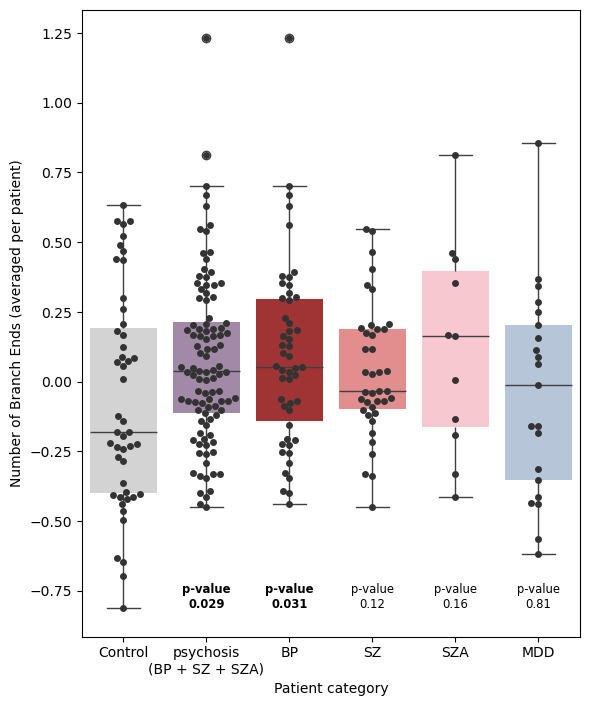

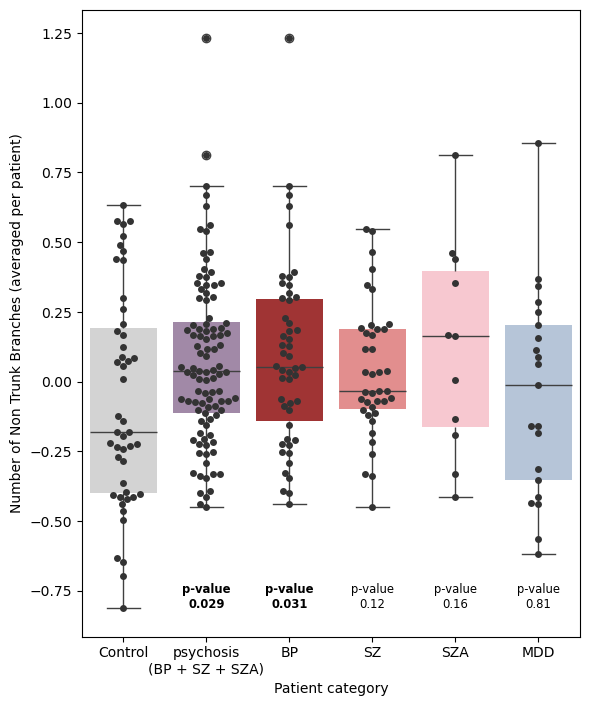

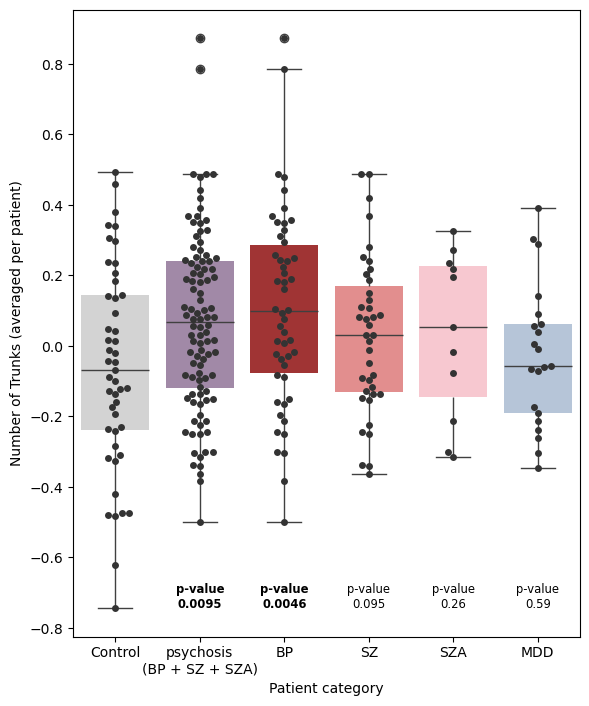

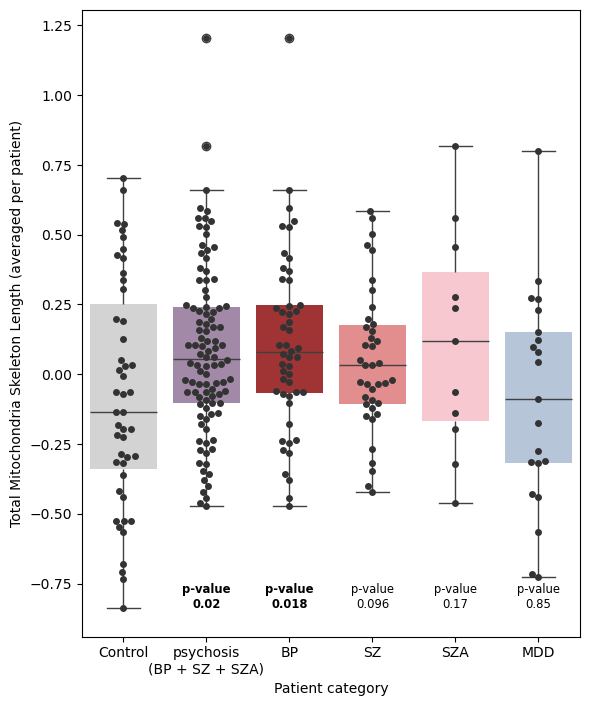

In [15]:
for targetFeature, nice_name, filename in [('Nuclei_ObjectSkeleton_NumberBranchEnds_mito_skel','Number of Branch Ends', 'branch_ends'),
                                 ('Nuclei_ObjectSkeleton_NumberBranchEnds_mito_skel', 'Number of Non Trunk Branches', 'non_trunk_branches'),
                                 ('Nuclei_ObjectSkeleton_NumberTrunks_mito_skel','Number of Trunks', 'num_trunks'),
                                 ('Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_mito_skel','Total Mitochondria Skeleton Length', 'skeleton_length')]:
    fig, axes = plt.subplots(1, 1, figsize=(6,7))
    orderC=["Control","psychosis","BP","SZ","SZA","MDD"]
    palette = ['lightgray','#a484ac','firebrick','lightcoral','pink','lightsteelblue']

    sns.boxplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
    sns.swarmplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes, color=".2")
    ############################
    mi,ma=data_phs[targetFeature].describe()[['min','max']]

    for i in range(len(orderC)):
        if orderC[i]!='Control':
            pval=round_sig(ttest_ind(data_phs.loc[data_phs['label']=='Control',targetFeature].values,\
                    data_phs.loc[data_phs['label']==orderC[i],targetFeature].values,equal_var=False).pvalue,2)
            print(pval)
            if pval<0.05:
                weight_f='bold'
            else:
                weight_f=None
            #axes.annotate('p-value\n'+str(pval),xy=(i,mi-0.12),horizontalalignment='center',size='small',weight=weight_f)
            axes.annotate('p-value\n'+str(pval),xy=(i,mi),horizontalalignment='center',size='small',weight=weight_f)

    axes.set(ylabel=f'{nice_name} (averaged per patient)')

    axes.set(xlabel='Patient category')
    plt.tight_layout()

    labels = [tick.get_text() for tick in axes.get_xticklabels()]
    labels[1] = "psychosis\n(BP + SZ + SZA)"
    axes.set_xticklabels(labels)
    
    if not os.path.exists('skel_features'):
        os.makedirs('skel_features')
    fig.savefig(os.path.join('skel_features',f"{filename}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join('skel_features',f"{filename}.png"), bbox_inches="tight")

/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/589490930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/589490930.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(labels)


0.11
0.19
0.089
0.5
0.0058


/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/589490930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/589490930.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(labels)


0.0086
0.014
0.033
0.059
0.14


/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/589490930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/589490930.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(labels)


0.01
0.023
0.03
0.059
0.13


/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/589490930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_92848/589490930.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(labels)


0.087
0.31
0.058
0.23
0.67


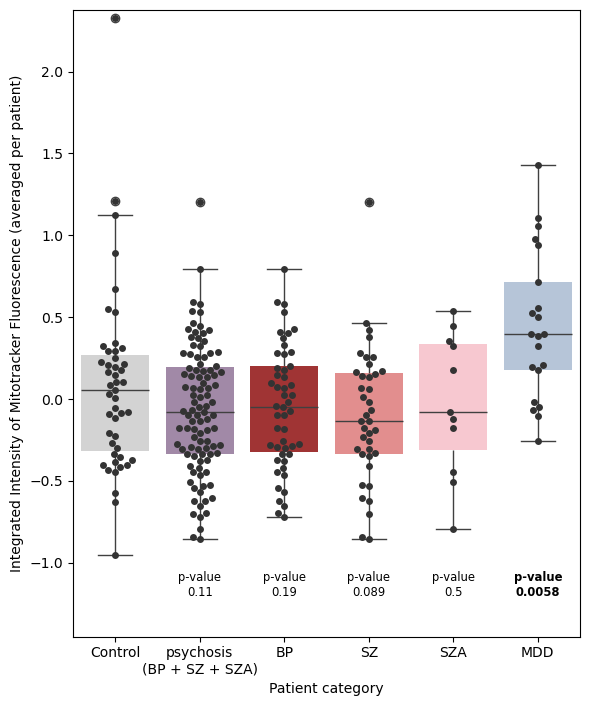

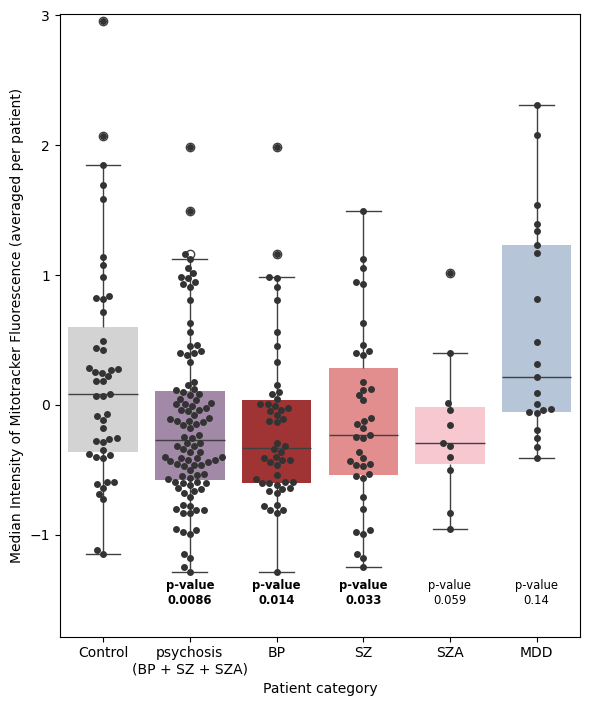

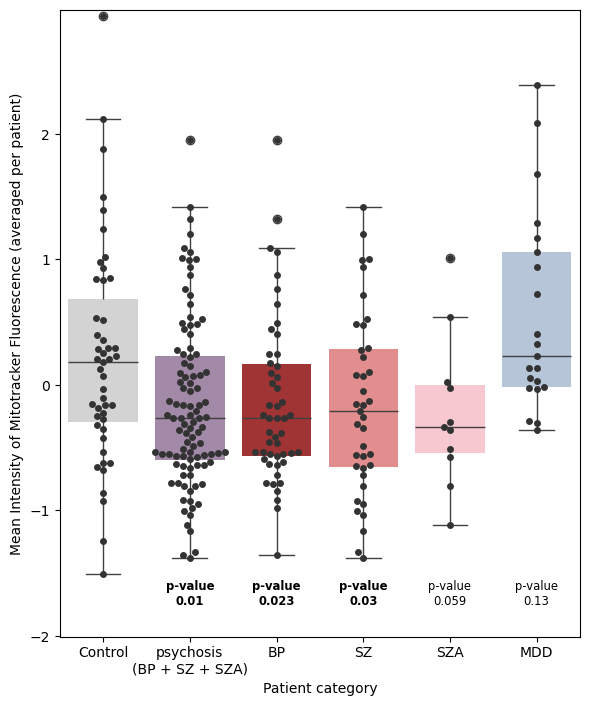

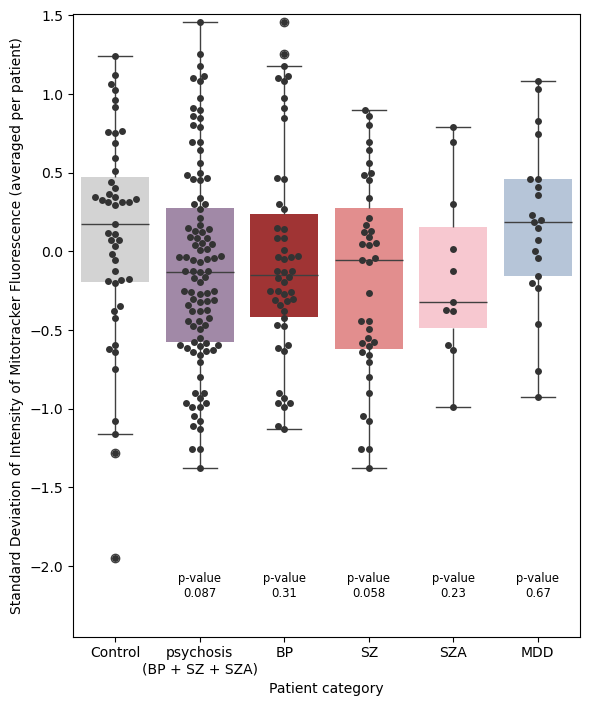

In [14]:
for targetFeature, nice_name, filename in [('Cells_Intensity_IntegratedIntensity_Mito','Integrated Intensity of Mitotracker Fluorescence', 'integrated_intensity'),
                                 ('Cells_Intensity_MedianIntensity_Mito', 'Median Intensity of Mitotracker Fluorescence', 'median_intensity'),
                                 ('Cells_Intensity_MeanIntensity_Mito','Mean Intensity of Mitotracker Fluorescence', 'mean_intensity'),
                                 ('Cells_Intensity_StdIntensity_Mito','Standard Deviation of Intensity of Mitotracker Fluorescence', 'std_intensity')]:
    fig, axes = plt.subplots(1, 1, figsize=(6,7))
    orderC=["Control","psychosis","BP","SZ","SZA","MDD"]
    palette = ['lightgray','#a484ac','firebrick','lightcoral','pink','lightsteelblue']

    sns.boxplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
    sns.swarmplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes, color=".2")
    ############################
    mi,ma=data_phs[targetFeature].describe()[['min','max']]

    for i in range(len(orderC)):
        if orderC[i]!='Control':
            pval=round_sig(ttest_ind(data_phs.loc[data_phs['label']=='Control',targetFeature].values,\
                    data_phs.loc[data_phs['label']==orderC[i],targetFeature].values,equal_var=False).pvalue,2)
            print(pval)
            if pval<0.05:
                weight_f='bold'
            else:
                weight_f=None
            axes.annotate('p-value\n'+str(pval),xy=(i,mi-0.25),horizontalalignment='center',size='small',weight=weight_f)
            #axes.annotate('p-value\n'+str(pval),xy=(i,mi),horizontalalignment='center',size='small',weight=weight_f)

    axes.set(ylabel=f'{nice_name} (averaged per patient)')
    axes.set_ylim([mi-0.5,ma+0.05])

    axes.set(xlabel='Patient category')
    plt.tight_layout()

    labels = [tick.get_text() for tick in axes.get_xticklabels()]
    labels[1] = "psychosis\n(BP + SZ + SZA)"
    axes.set_xticklabels(labels)
    
    if not os.path.exists('intensity_features'):
        os.makedirs('intensity_features')
    fig.savefig(os.path.join('intensity_features',f"{filename}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join('intensity_features',f"{filename}.png"), bbox_inches="tight")

In [ ]:
for targetFeature, nice_name, filename in [('Cells_Intensity_IntegratedIntensity_Mito','Integrated Intensity of Mitotracker Fluorescence', 'integrated_intensity'),
                                 ('Cells_Intensity_MedianIntensity_Mito', 'Median Intensity of Mitotracker Fluorescence', 'median_intensity'),
                                 ('Cells_Intensity_MeanIntensity_Mito','Mean Intensity of Mitotracker Fluorescence', 'mean_intensity'),
                                 ('Cells_Intensity_StdIntensity_Mito','Standard Deviation of Intensity of Mitotracker Fluorescence', 'std_intensity')]:
    fig, axes = plt.subplots(1, 1, figsize=(6,7))
    orderC=["Control","psychosis","BP","SZ","SZA","MDD"]
    palette = ['lightgray','#a484ac','firebrick','lightcoral','pink','lightsteelblue']

    sns.boxplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
    sns.swarmplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes, color=".2")
    ############################
    mi,ma=data_phs[targetFeature].describe()[['min','max']]

    for i in range(len(orderC)):
        if orderC[i]!='Control':
            pval=round_sig(ttest_ind(data_phs.loc[data_phs['label']=='Control',targetFeature].values,\
                    data_phs.loc[data_phs['label']==orderC[i],targetFeature].values,equal_var=False).pvalue,2)
            print(pval)
            if pval<0.05:
                weight_f='bold'
            else:
                weight_f=None
            axes.annotate('p-value\n'+str(pval),xy=(i,mi-0.25),horizontalalignment='center',size='small',weight=weight_f)
            #axes.annotate('p-value\n'+str(pval),xy=(i,mi),horizontalalignment='center',size='small',weight=weight_f)

    axes.set(ylabel=f'{nice_name} (averaged per patient)')
    axes.set_ylim([mi-0.5,ma+0.05])

    axes.set(xlabel='Patient category')
    plt.tight_layout()

    labels = [tick.get_text() for tick in axes.get_xticklabels()]
    labels[1] = "psychosis\n(BP + SZ + SZA)"
    axes.set_xticklabels(labels)
    
    if not os.path.exists('intensity_features'):
        os.makedirs('intensity_features')
    fig.savefig(os.path.join('intensity_features',f"{filename}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join('intensity_features',f"{filename}.png"), bbox_inches="tight")